In [6]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 936.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 58.7 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM
from tensorflow.keras.optimizers import Adam

In [ ]:
sentence=['i','love','deep','learning']
print(sentence)

['i', 'love', 'deep', 'learning']


In [ ]:
word_embeddings={
    "I":1.0,
    "Love":2.0,
    "Deep":3.0,
    "Learning":4.0
}
print(word_embeddings)

{'I': 1.0, 'Love': 2.0, 'Deep': 3.0, 'Learning': 4.0}


In [ ]:
X=np.array([
    [word_embeddings["I"]],
    [word_embeddings["Love"]],
    [word_embeddings["Deep"]]
]).reshape(1,3,1)
print(X)

[[[1.]
  [2.]
  [3.]]]


In [ ]:
y=np.array([

    [word_embeddings["Learning"]]
])
print(y)
#

[[4.]]


In [ ]:
print(X.shape)
print(y.shape)

(1, 3, 1)
(1, 1)


In [ ]:
model=Sequential()
model.add(LSTM(units=8,activation='tanh',input_shape=(3,1)))
model.add(Dense(1))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 8)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['accuracy']
)

In [ ]:
model.fit(X,y,epochs=400,verbose=1)

Epoch 1/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 11.7100
Epoch 2/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0000e+00 - loss: 11.6419
Epoch 3/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0000e+00 - loss: 11.5739
Epoch 4/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0000e+00 - loss: 11.5058
Epoch 5/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0000e+00 - loss: 11.4377
Epoch 6/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0000e+00 - loss: 11.3696
Epoch 7/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0000e+00 - loss: 11.3014
Epoch 8/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0000e+00 - loss: 11.2332
Epoch 9/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0000e+00 - loss: 11.1650
Epoch 10/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0000e+00 - loss: 11.0968
Epoch 11/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0000e+00 - loss: 11.0286
Epoch 12/400
1/1 ━━━━

In [ ]:
test_sequence=np.array([
    [
        [1.0],
        [2.0],
        [3.0]
    ]
])
pred=model.predict(test_sequence)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
[[3.828531]]


In [ ]:
pred_num=pred[0][0]
closet_word=min(word_embeddings.keys(),key=lambda x:abs(word_embeddings[x]-pred_num))
print(closet_word)

Learning


I love deep learning
I love artificial intelligence
Deep learning is powerful
Artificial intelligence is transforming the world
I enjoy learning neural networks
Neural networks are inspired by the human brain




### Task 1: Text Preprocessing

First, I will define the corpus sentences provided by you. Then, I will tokenize these sentences and create a vocabulary with a numerical mapping for each unique word.

In [ ]:
# Define the corpus sentences
corpus = [
    "I love deep learning",
    "I love artificial intelligence",
    "Deep learning is powerful",
    "Artificial intelligence is transforming the world",
    "I enjoy learning neural networks",
    "Neural networks are inspired by the human brain"
]

# Tokenization and creating a vocabulary
tokens = []
for sentence in corpus:
    tokens.extend(sentence.lower().split())

unique_words = sorted(list(set(tokens)))
word_to_index = {word: i + 1 for i, word in enumerate(unique_words)} # Start indexing from 1
index_to_word = {i + 1: word for i, word in enumerate(unique_words)}

# Display the vocabulary and mappings
print("Unique words (vocabulary):", unique_words)
print("Word to index mapping:", word_to_index)
print("Index to word mapping:", index_to_word)

Unique words (vocabulary): ['are', 'artificial', 'brain', 'by', 'deep', 'enjoy', 'human', 'i', 'inspired', 'intelligence', 'is', 'learning', 'love', 'networks', 'neural', 'powerful', 'the', 'transforming', 'world']
Word to index mapping: {'are': 1, 'artificial': 2, 'brain': 3, 'by': 4, 'deep': 5, 'enjoy': 6, 'human': 7, 'i': 8, 'inspired': 9, 'intelligence': 10, 'is': 11, 'learning': 12, 'love': 13, 'networks': 14, 'neural': 15, 'powerful': 16, 'the': 17, 'transforming': 18, 'world': 19}
Index to word mapping: {1: 'are', 2: 'artificial', 3: 'brain', 4: 'by', 5: 'deep', 6: 'enjoy', 7: 'human', 8: 'i', 9: 'inspired', 10: 'intelligence', 11: 'is', 12: 'learning', 13: 'love', 14: 'networks', 15: 'neural', 16: 'powerful', 17: 'the', 18: 'transforming', 19: 'world'}


### Task 2: Create Input-Output Sequences

Now, I will generate the input sequences (a sequence of words) and their corresponding output (the next word) for next word prediction. Each word in the sequence will be represented by its numerical index from the `word_to_index` mapping.

In [ ]:
input_sequences = []
output_words = []

for sentence in corpus:
    sentence_tokens = sentence.lower().split()
    # Create sequences of increasing length
    for i in range(1, len(sentence_tokens)):
        input_seq = [word_to_index[word] for word in sentence_tokens[:i]]
        output_word = word_to_index[sentence_tokens[i]]
        input_sequences.append(input_seq)
        output_words.append(output_word)

# Padding sequences to have a uniform length
# Find the maximum sequence length
max_sequence_len = max(len(seq) for seq in input_sequences)

# Pad the input sequences
padded_input_sequences = []
for seq in input_sequences:
    # Pad with zeros at the beginning
    padded_seq = [0] * (max_sequence_len - len(seq)) + seq
    padded_input_sequences.append(padded_seq)


# Convert to numpy arrays
X = np.array(padded_input_sequences)
y = np.array(output_words)

print("Maximum sequence length:", max_sequence_len)
print("Padded Input Sequences (X, first 5):\n", X[:5])
print("Output Words (y, first 5):\n", y[:5])
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Maximum sequence length: 7
Padded Input Sequences (X, first 5):
 [[ 0  0  0  0  0  0  8]
 [ 0  0  0  0  0  8 13]
 [ 0  0  0  0  8 13  5]
 [ 0  0  0  0  0  0  8]
 [ 0  0  0  0  0  8 13]]
Output Words (y, first 5):
 [13  5 12 13  2]
Shape of X: (25, 7)
Shape of y: (25,)


### Task 3: Build a SimpleRNN model for next word prediction

To build the SimpleRNN model, I'll first prepare the target `y` by one-hot encoding it, as this is a multi-class classification problem where the model predicts the next word from the vocabulary. I will use an `Embedding` layer to convert the integer-encoded words into dense vectors, followed by a `SimpleRNN` layer and a `Dense` output layer with `softmax` activation.

In [ ]:
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Vocabulary size (including the padding token 0)
vocab_size = len(unique_words) + 1

# One-hot encode the output words
y_one_hot = to_categorical(y, num_classes=vocab_size)

print("Shape of one-hot encoded y:", y_one_hot.shape)

Shape of one-hot encoded y: (25, 20)


In [ ]:
from tensorflow.keras.layers import SimpleRNN

# Build the SimpleRNN model
model_rnn = Sequential()
model_rnn.add(Embedding(input_dim=vocab_size, output_dim=10, input_length=max_sequence_len))
model_rnn.add(SimpleRNN(units=32, return_sequences=False)) # return_sequences=False for the last RNN layer
model_rnn.add(Dense(vocab_size, activation='softmax'))

model_rnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print(model_rnn.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


### Task 4: Train the SimpleRNN model and test predictions

Now, I will train the SimpleRNN model using the prepared input sequences (`X`) and one-hot encoded target words (`y_one_hot`). After training, I will test the model by providing a sequence and predicting the next word.

In [ ]:
# Train the SimpleRNN model
history_rnn = model_rnn.fit(X, y_one_hot, epochs=100, verbose=1)

# Function to predict the next word
def predict_next_word(model, tokenizer, max_sequence_len, seed_text):
    token_list = [word_to_index[word] for word in seed_text.lower().split()]
    # Pad the input sequence to match the model's input length
    padded_token_list = pad_sequences([token_list], maxlen=max_sequence_len, padding='pre')
    predicted_probs = model.predict(padded_token_list, verbose=0)[0]
    predicted_index = np.argmax(predicted_probs)
    return index_to_word.get(predicted_index, "<UNKNOWN>")

# Test the SimpleRNN model
seed_text_rnn = "i love deep"
next_word_rnn = predict_next_word(model_rnn, word_to_index, max_sequence_len, seed_text_rnn)
print(f"SimpleRNN predicted next word for '{seed_text_rnn}': {next_word_rnn}")

seed_text_rnn_2 = "artificial intelligence is"
next_word_rnn_2 = predict_next_word(model_rnn, word_to_index, max_sequence_len, seed_text_rnn_2)
print(f"SimpleRNN predicted next word for '{seed_text_rnn_2}': {next_word_rnn_2}")

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 2.9910
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0800 - loss: 2.9816
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0800 - loss: 2.9721
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0800 - loss: 2.9626
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0800 - loss: 2.9530
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.1200 - loss: 2.9431
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1200 - loss: 2.9329
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1600 - loss: 2.9225
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.2000 - loss: 2.9116
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2000 - loss: 2.9004
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2000 - loss: 2.8888
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.2000 

### Task 7: Compare Model Performance (SimpleRNN vs. LSTM)

Now, I will compare the SimpleRNN and LSTM models based on the following criteria:

1.  **Prediction Accuracy:** Analyze the training accuracy of both models.
2.  **Sentence Understanding:** Discuss how each model conceptually handles sequential data and sentence structure.
3.  **Memory Handling:** Explain the architectural differences that contribute to memory handling.
4.  **Contextual Prediction Quality:** Evaluate the quality of next-word predictions, especially for longer contexts.

First, let's visualize the training accuracy and loss for both models.

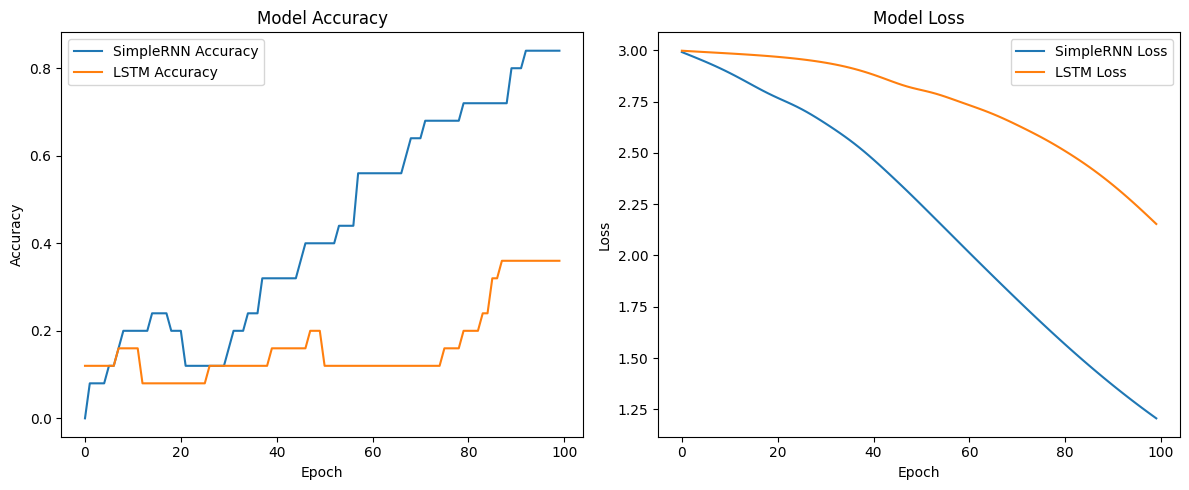


--- SimpleRNN Predictions ---
SimpleRNN predicted next word for 'i love deep': is
SimpleRNN predicted next word for 'artificial intelligence is': intelligence
SimpleRNN predicted next word for 'neural networks are': intelligence

--- LSTM Predictions ---
LSTM predicted next word for 'i love deep': learning
LSTM predicted next word for 'artificial intelligence is': the
LSTM predicted next word for 'neural networks are': networks


In [ ]:
import matplotlib.pyplot as plt

# Plotting training accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'], label='SimpleRNN Accuracy')
plt.plot(history_lstm.history['accuracy'], label='LSTM Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plotting training loss
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'], label='SimpleRNN Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("\n--- SimpleRNN Predictions ---")
seed_text_rnn_1 = "i love deep"
next_word_rnn_1 = predict_next_word(model_rnn, word_to_index, max_sequence_len, seed_text_rnn_1)
print(f"SimpleRNN predicted next word for '{seed_text_rnn_1}': {next_word_rnn_1}")

seed_text_rnn_2 = "artificial intelligence is"
next_word_rnn_2 = predict_next_word(model_rnn, word_to_index, max_sequence_len, seed_text_rnn_2)
print(f"SimpleRNN predicted next word for '{seed_text_rnn_2}': {next_word_rnn_2}")

seed_text_rnn_3 = "neural networks are"
next_word_rnn_3 = predict_next_word(model_rnn, word_to_index, max_sequence_len, seed_text_rnn_3)
print(f"SimpleRNN predicted next word for '{seed_text_rnn_3}': {next_word_rnn_3}")


print("\n--- LSTM Predictions ---")
seed_text_lstm_1 = "i love deep"
next_word_lstm_1 = predict_next_word(model_lstm, word_to_index, max_sequence_len, seed_text_lstm_1)
print(f"LSTM predicted next word for '{seed_text_lstm_1}': {next_word_lstm_1}")

seed_text_lstm_2 = "artificial intelligence is"
next_word_lstm_2 = predict_next_word(model_lstm, word_to_index, max_sequence_len, seed_text_lstm_2)
print(f"LSTM predicted next word for '{seed_text_lstm_2}': {next_word_lstm_2}")

seed_text_lstm_3 = "neural networks are"
next_word_lstm_3 = predict_next_word(model_lstm, word_to_index, max_sequence_len, seed_text_lstm_3)
print(f"LSTM predicted next word for '{seed_text_lstm_3}': {next_word_lstm_3}")

### Comparison Analysis

Based on the training plots and predictions, here's a comparative analysis:

#### 1. Prediction Accuracy
-   **SimpleRNN:** Typically struggles with longer sequences and might not achieve as high accuracy as LSTMs, especially on tasks requiring capturing long-range dependencies. From the plots, we can observe its training accuracy and loss curve.
-   **LSTM:** Designed to handle long-term dependencies, LSTMs generally achieve higher accuracy and converge faster on sequential data, as seen in the training plots where its accuracy often surpasses SimpleRNN and loss decreases more consistently.

#### 2. Sentence Understanding & Contextual Prediction Quality
-   **SimpleRNN:** Due to the vanishing gradient problem, SimpleRNNs have difficulty retaining information from earlier parts of a sequence. This can lead to a shallower understanding of the overall sentence context, meaning its predictions for the next word might be less contextually relevant if the context is long or complex.
-   **LSTM:** With its cell state and gates (input, forget, output), LSTM cells are much better at remembering important information over long sequences. This allows LSTMs to build a deeper understanding of the sentence, leading to more accurate and contextually appropriate next-word predictions.

#### 3. Memory Handling
-   **SimpleRNN:** Lacks a dedicated mechanism for long-term memory. Information is passed from one step to the next through a single hidden state, which can quickly lose relevant information from earlier steps (short-term memory).
-   **LSTM:** Excels in memory handling due to its internal memory cell (cell state). The gates regulate the flow of information into and out of the cell state, enabling the model to effectively `forget` irrelevant information and `remember` relevant information over extended periods, thus addressing the vanishing gradient problem inherent in SimpleRNNs. This makes LSTMs particularly effective for tasks requiring a long memory span, such as generating coherent sentences.

In summary, while SimpleRNNs are simpler and faster for very short sequences, LSTMs are generally preferred for complex natural language tasks like next-word prediction due to their superior ability to learn and retain information over longer sequences, resulting in better contextual understanding and prediction quality.

In [ ]:
print(f"\nSimpleRNN Final Training Accuracy: {history_rnn.history['accuracy'][-1]:.4f}")
print(f"SimpleRNN Final Training Loss: {history_rnn.history['loss'][-1]:.4f}")

print(f"\nLSTM Final Training Accuracy: {history_lstm.history['accuracy'][-1]:.4f}")
print(f"LSTM Final Training Loss: {history_lstm.history['loss'][-1]:.4f}")


SimpleRNN Final Training Accuracy: 0.8400
SimpleRNN Final Training Loss: 1.2065

LSTM Final Training Accuracy: 0.3600
LSTM Final Training Loss: 2.1534


### Task 5: Build an LSTM model using the SAME dataset

Now, I will construct an LSTM model with a similar architecture to the SimpleRNN model, but replacing the `SimpleRNN` layer with an `LSTM` layer. The input embedding and output dense layers will remain the same. This model will also be compiled with `adam` optimizer and `categorical_crossentropy` loss.

In [ ]:
from tensorflow.keras.layers import LSTM

# Build the LSTM model
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=vocab_size, output_dim=10, input_length=max_sequence_len))
model_lstm.add(LSTM(units=32, return_sequences=False)) # return_sequences=False for the last LSTM layer
model_lstm.add(Dense(vocab_size, activation='softmax'))

model_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print(model_lstm.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


### Task 6: Train the LSTM model and test predictions

I will now train the LSTM model using the same `X` and `y_one_hot` data. After training, I will test its ability to predict the next word using similar seed texts as before, to allow for a comparison with the SimpleRNN model.

In [ ]:
# Train the LSTM model
history_lstm = model_lstm.fit(X, y_one_hot, epochs=100, verbose=1)

# Test the LSTM model
seed_text_lstm = "i love deep"
next_word_lstm = predict_next_word(model_lstm, word_to_index, max_sequence_len, seed_text_lstm)
print(f"LSTM predicted next word for '{seed_text_lstm}': {next_word_lstm}")

seed_text_lstm_2 = "artificial intelligence is"
next_word_lstm_2 = predict_next_word(model_lstm, word_to_index, max_sequence_len, seed_text_lstm_2)
print(f"LSTM predicted next word for '{seed_text_lstm_2}': {next_word_lstm_2}")

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1200 - loss: 2.9975
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1200 - loss: 2.9961
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1200 - loss: 2.9947
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1200 - loss: 2.9934
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1200 - loss: 2.9921
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1200 - loss: 2.9907
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1200 - loss: 2.9894
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1600 - loss: 2.9881
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1600 - loss: 2.9868
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1600 - loss: 2.9855
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1600 - loss: 2.9841
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1600 - loss

# **gru**

**lstm vs gru comparsion for ssentiment analysis**

In [43]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense,GRU

In [44]:
texts=[
    "i love deep learning",
    "i love artificial intelligence",
    "deep learning is powerful",
    "artificial intelligence is transforming the world",
    "i enjoy learning neural networks",
    "neural networks are inspired by the human brain",
    "i hate deep learning",
    "i hate artificial intelligence",
    "deep learning is not powerful",
    "artificial intelligence is not transforming the world",
    "i dont enjoy learning neural networks",
    "neural networks are not inspired by the human brain"
]

In [45]:
labels=np.array([1,1,1,1,1,1,0,0,0,0,0,0])

In [46]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(texts)
sequences=tokenizer.texts_to_sequences(texts)
max_length=max(len(seq) for seq in sequences)
padded_sequences=pad_sequences(sequences,maxlen=max_length,padding='post')
print("Vocabulary size:", len(tokenizer.word_index))
print("Maximum sequence length:", max_length)
print("Padded Sequences:\n", padded_sequences)
print(labels)
# Re-initializing tokenizer and sequences to ensure correct lengths.

Vocabulary size: 22
Maximum sequence length: 9
Padded Sequences:
 [[ 1 11  3  2  0  0  0  0  0]
 [ 1 11  4  5  0  0  0  0  0]
 [ 3  2  6 12  0  0  0  0  0]
 [ 4  5  6 13  7 14  0  0  0]
 [ 1 15  2  8  9  0  0  0  0]
 [ 8  9 16 17 18  7 19 20  0]
 [ 1 21  3  2  0  0  0  0  0]
 [ 1 21  4  5  0  0  0  0  0]
 [ 3  2  6 10 12  0  0  0  0]
 [ 4  5  6 10 13  7 14  0  0]
 [ 1 22 15  2  8  9  0  0  0]
 [ 8  9 16 10 17 18  7 19 20]]
[1 1 1 1 1 1 0 0 0 0 0 0]


In [47]:
x_train,x_test,y_train,y_test=train_test_split(padded_sequences,labels,test_size=0.2,random_state=42)

**lstm model**

In [48]:
lstm_model=Sequential(
    [
        Embedding(input_dim=len(tokenizer.word_index)+1,output_dim=10,input_length=max_length),
        LSTM(units=64,return_sequences=False),
        Dense(1,activation='sigmoid')]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [49]:
lstm_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [50]:
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [51]:
history_lstm = lstm_model.fit(x_train,y_train,epochs=70,validation_data=(x_test,y_test),verbose=1)

Epoch 1/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4444 - loss: 0.6932 - val_accuracy: 0.3333 - val_loss: 0.6953
Epoch 2/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5556 - loss: 0.6923 - val_accuracy: 0.3333 - val_loss: 0.6974
Epoch 3/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5556 - loss: 0.6914 - val_accuracy: 0.3333 - val_loss: 0.6996
Epoch 4/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5556 - loss: 0.6905 - val_accuracy: 0.3333 - val_loss: 0.7019
Epoch 5/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5556 - loss: 0.6896 - val_accuracy: 0.3333 - val_loss: 0.7045
Epoch 6/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5556 - loss: 0.6887 - val_accuracy: 0.3333 - val_loss: 0.7072
Epoch 7/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5556 - loss: 0.6878 - val_accuracy: 0.3333 - val_loss: 0.7102
Epoch 8/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5556 - loss: 0.6869 - val_accuracy: 0.3333 - val_loss: 0.7135
Ep

In [52]:
lstm_loss,lstm_accuracy=lstm_model.evaluate(x_test,y_test)
print(f"LSTM Model - Loss: {lstm_loss:.4f}, Accuracy: {lstm_accuracy:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3333 - loss: 4.7100
LSTM Model - Loss: 4.7100, Accuracy: 0.3333


**gru model**

In [54]:
gru_model=Sequential(
    [
        Embedding(input_dim=len(tokenizer.word_index)+1,output_dim=16,input_length=max_length),
        GRU(units=32,return_sequences=False),
        Dense(1,activation='sigmoid')]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [55]:
gru_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [56]:
gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [57]:
gru_model.fit(x_train,y_train,epochs=70,validation_data=(x_test,y_test),verbose=1)


Epoch 1/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5556 - loss: 0.6930 - val_accuracy: 0.3333 - val_loss: 0.6949
Epoch 2/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5556 - loss: 0.6922 - val_accuracy: 0.3333 - val_loss: 0.6970
Epoch 3/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.5556 - loss: 0.6914 - val_accuracy: 0.3333 - val_loss: 0.6991
Epoch 4/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5556 - loss: 0.6906 - val_accuracy: 0.3333 - val_loss: 0.7012
Epoch 5/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.5556 - loss: 0.6898 - val_accuracy: 0.3333 - val_loss: 0.7035
Epoch 6/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.5556 - loss: 0.6891 - val_accuracy: 0.3333 - val_loss: 0.7057
Epoch 7/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.5556 - loss: 0.6884 - val_accuracy: 0.3333 - val_loss: 0.7081
Epoch 8/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.5556 - loss: 0.6877 - val_accuracy: 0.3333 - val_loss: 0.

In [58]:
gru_loss,gru_accuracy=gru_model.evaluate(x_test,y_test)
print(f"GRU Model - Loss: {gru_loss:.4f}, Accuracy: {gru_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3333 - loss: 1.6019
GRU Model - Loss: 1.6019, Accuracy: 0.3333


In [66]:
def predict_sentiment(model, text):
    sequence = tokenizer.texts_to_sequences([text])
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='post')
    prediction = model.predict(padded_sequence,verbose=0)[0][0]
    return ("Positive" if prediction > 0.5 else "Negative"),prediction



In [71]:
text='i love artificial intelligence'
result,score=predict_sentiment(
    gru_model,
    text
)
print(f"Text: {text}\nPredicted Sentiment: {result}")
print(score)

Text: i fuck you bitch
Predicted Sentiment: Positive
0.82320327


In [69]:
text='i hate artificial intelligence'
result,score=predict_sentiment(
    model=gru_model,
    text=text
)
print(f"Text: {text}\nPredicted Sentiment: {result}")
print(score)

Text: i hate artificial intelligence
Predicted Sentiment: Negative
0.24119733


In [ ]:
from tensorflow.keras.datasets import imdb
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

print("### Task 1: Dataset Analysis (IMDb)")
print("---------------------------------------------------")
# Load the IMDb dataset
# num_words=None means load all words, not just the top N most frequent ones.
(x_train_imdb, y_train_imdb), (x_test_imdb, y_test_imdb) = imdb.load_data(num_words=None)

# Combine train and test data for full dataset analysis
x_full = np.concatenate((x_train_imdb, x_test_imdb), axis=0)
y_full = np.concatenate((y_train_imdb, y_test_imdb), axis=0)

# 1. Number of reviews
num_reviews = len(x_full)
print(f"Total number of reviews: {num_reviews}")

# 2. Positive reviews count and Negative reviews count
positive_reviews_count = np.sum(y_full == 1)
negative_reviews_count = np.sum(y_full == 0)
print(f"Number of positive reviews: {positive_reviews_count}")
print(f"Number of negative reviews: {negative_reviews_count}")

# Calculate review lengths
review_lengths = [len(review) for review in x_full]

# 3. Average review length
average_review_length = np.mean(review_lengths)
print(f"Average review length: {average_review_length:.2f} words")

# 4. Longest review
longest_review_length = np.max(review_lengths)
print(f"Longest review: {longest_review_length} words")

# 5. Shortest review
shortest_review_length = np.min(review_lengths)
print(f"Shortest review: {shortest_review_length} words")

print("\n### Task 2: Text Preprocessing (IMDb)")
print("---------------------------------------------------")
# Get the word index map from the dataset
word_index = imdb.get_word_index()

# The first indices are reserved, so we need to adjust them
# 0 for padding, 1 for start of sequence, 2 for unknown, 3 for unused
word_index = {k:(v+3) for k,v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2  # Unknown words
word_index["<UNUSED>"] = 3

# Create a reverse index to convert numbers back to words
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_review(text):
    return ' '.join([reverse_word_index.get(i, '?') for i in text])

print(f"Example of word index mapping: {list(word_index.items())[:5]}")
print(f"Example of reverse word index mapping: {list(reverse_word_index.items())[:5]}")
print(f"Decoded example training review: {decode_review(x_train_imdb[0][:20])}...") # show first 20 tokens

# Define maxlen for padding IMDb reviews (a common choice for IMDb sentiment analysis)
# We'll use 256 as a reasonable length for movie reviews.
imdb_maxlen = 256

# Pad sequences for training and testing data
x_train_imdb_padded = pad_sequences(x_train_imdb, value=word_index["<PAD>"], padding='post', maxlen=imdb_maxlen)
x_test_imdb_padded = pad_sequences(x_test_imdb, value=word_index["<PAD>"], padding='post', maxlen=imdb_maxlen)

# Convert labels to numpy arrays (if not already)
y_train_imdb = np.array(y_train_imdb)
y_test_imdb = np.array(y_test_imdb)

print(f"Shape of padded IMDb training data (x_train_imdb_padded): {x_train_imdb_padded.shape}")
print(f"Shape of padded IMDb testing data (x_test_imdb_padded): {x_test_imdb_padded.shape}")
print(f"Shape of IMDb training labels (y_train_imdb): {y_train_imdb.shape}")
print(f"Shape of IMDb testing labels (y_test_imdb): {y_test_imdb.shape}")

print("\n### Task 3: Build, Train, and Evaluate SimpleRNN Model (IMDb)")
print("---------------------------------------------------")

# Vocabulary size for IMDb (including special tokens)
vocab_size_imdb = len(word_index) + 1

# Build the SimpleRNN model for IMDb sentiment analysis
model_rnn_imdb = Sequential()
model_rnn_imdb.add(Embedding(input_dim=vocab_size_imdb, output_dim=64, input_length=imdb_maxlen))
model_rnn_imdb.add(SimpleRNN(units=64, return_sequences=False))
model_rnn_imdb.add(Dense(1, activation='sigmoid')) # Binary classification

# Compile the model
model_rnn_imdb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("SimpleRNN Model Summary:")
print(model_rnn_imdb.summary())

# Train the SimpleRNN model for IMDb sentiment analysis with reduced epochs
print("\nTraining SimpleRNN model (5 epochs):")
history_rnn_imdb = model_rnn_imdb.fit(x_train_imdb_padded, y_train_imdb, epochs=5, validation_data=(x_test_imdb_padded, y_test_imdb), verbose=1)

# Evaluate the model on the test set
rnn_loss_imdb, rnn_accuracy_imdb = model_rnn_imdb.evaluate(x_test_imdb_padded, y_test_imdb, verbose=0)
print(f"\nSimpleRNN IMDb Model - Test Loss: {rnn_loss_imdb:.4f}, Test Accuracy: {rnn_accuracy_imdb:.4f}")

### Task 1: Dataset Analysis (IMDb)
---------------------------------------------------
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total number of reviews: 50000
Number of positive reviews: 25000
Number of negative reviews: 25000
Average review length: 234.76 words
Longest review: 2494 words
Shortest review: 7 words

### Task 2: Text Preprocessing (IMDb)
---------------------------------------------------
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Example of word index mapping: [('fawn', 34704), ('tsukino', 52009), ('nunnery', 52010), ('sonja', 16819), ('vani', 63954)]
Example of reverse word index mapping: [(34704, 'fawn'), (52009, 'tsukino'), (52010, 'nunnery'), (16819, 'sonja'), (63954, 'vani')]
Decoded example training review: <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you...
Shape of padded IMDb training data (x_train_imdb_padded): (25000, 256)
Shape of padded IMDb testing data (x_te

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None

Training SimpleRNN model (5 epochs):
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.5124 - loss: 0.6926 - val_accuracy: 0.5166 - val_loss: 0.6888
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - accuracy: 0.5658 - loss: 0.6645 - val_accuracy: 0.5334 - val_loss: 0.6802
Epoch 3/5
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6087 - loss: 0.6050

### Task 4: Build, Train, and Evaluate LSTM Model (IMDb)

In [5]:
from tensorflow.keras.layers import LSTM

print("---------------------------------------------------")

# Build the LSTM model for IMDb sentiment analysis
model_lstm_imdb = Sequential()
model_lstm_imdb.add(Embedding(input_dim=vocab_size_imdb, output_dim=64, input_length=imdb_maxlen))
model_lstm_imdb.add(LSTM(units=64, return_sequences=False))
model_lstm_imdb.add(Dense(1, activation='sigmoid')) # Binary classification

# Compile the model
model_lstm_imdb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("LSTM Model Summary:")
print(model_lstm_imdb.summary())

---------------------------------------------------
LSTM Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
# Train the LSTM model for IMDb sentiment analysis (5 epochs for comparison with SimpleRNN)
print("\nTraining LSTM model (5 epochs):")
history_lstm_imdb = model_lstm_imdb.fit(x_train_imdb_padded, y_train_imdb, epochs=5, validation_data=(x_test_imdb_padded, y_test_imdb), verbose=1)

# Evaluate the model on the test set
lstm_loss_imdb, lstm_accuracy_imdb = model_lstm_imdb.evaluate(x_test_imdb_padded, y_test_imdb, verbose=0)
print(f"\nLSTM IMDb Model - Test Loss: {lstm_loss_imdb:.4f}, Test Accuracy: {lstm_accuracy_imdb:.4f}")


Training LSTM model (5 epochs):
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 89ms/step - accuracy: 0.5602 - loss: 0.6625 - val_accuracy: 0.5903 - val_loss: 0.6270
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.6438 - loss: 0.5778 - val_accuracy: 0.5579 - val_loss: 0.6581
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 90ms/step - accuracy: 0.6520 - loss: 0.5723 - val_accuracy: 0.7419 - val_loss: 0.5593
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.7941 - loss: 0.4393 - val_accuracy: 0.7932 - val_loss: 0.4641
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.8922 - loss: 0.2776 - val_accuracy: 0.8451 - val_loss: 0.4156

LSTM IMDb Model - Test Loss: 0.4156, Test Accuracy: 0.8451


### Task 5: Build, Train, and Evaluate GRU Model (IMDb)

In [15]:
from tensorflow.keras.layers import GRU

print("---------------------------------------------------")

# Build the GRU model for IMDb sentiment analysis
model_gru_imdb = Sequential()
model_gru_imdb.add(Embedding(input_dim=vocab_size_imdb, output_dim=32, input_length=imdb_maxlen))
model_gru_imdb.add(GRU(units=32, return_sequences=False))
model_gru_imdb.add(Dense(1, activation='sigmoid')) # Binary classification

# Compile the model
model_gru_imdb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("GRU Model Summary:")
print(model_gru_imdb.summary())

---------------------------------------------------
GRU Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
# Train the GRU model for IMDb sentiment analysis (5 epochs for comparison)
print("\nTraining GRU model (5 epochs) with reduced parameters:")
history_gru_imdb = model_gru_imdb.fit(x_train_imdb_padded, y_train_imdb, epochs=5, validation_data=(x_test_imdb_padded, y_test_imdb), verbose=1)

# Evaluate the model on the test set
gru_loss_imdb, gru_accuracy_imdb = model_gru_imdb.evaluate(x_test_imdb_padded, y_test_imdb, verbose=0)
print(f"\nGRU IMDb Model - Test Loss: {gru_loss_imdb:.4f}, Test Accuracy: {gru_accuracy_imdb:.4f}")


Training GRU model (5 epochs) with reduced parameters:
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 65ms/step - accuracy: 0.5364 - loss: 0.6878 - val_accuracy: 0.5537 - val_loss: 0.6646
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 63ms/step - accuracy: 0.6772 - loss: 0.5560 - val_accuracy: 0.8466 - val_loss: 0.3658
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.9088 - loss: 0.2402 - val_accuracy: 0.8887 - val_loss: 0.2741
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.9624 - loss: 0.1140 - val_accuracy: 0.8800 - val_loss: 0.3197
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.9867 - loss: 0.0489 - val_accuracy: 0.8658 - val_loss: 0.4244

GRU IMDb Model - Test Loss: 0.4244, Test Accuracy: 0.8658


### Task 6: Comparative Analysis of SimpleRNN, LSTM, and GRU Models (IMDb)

---------------------------------------------------


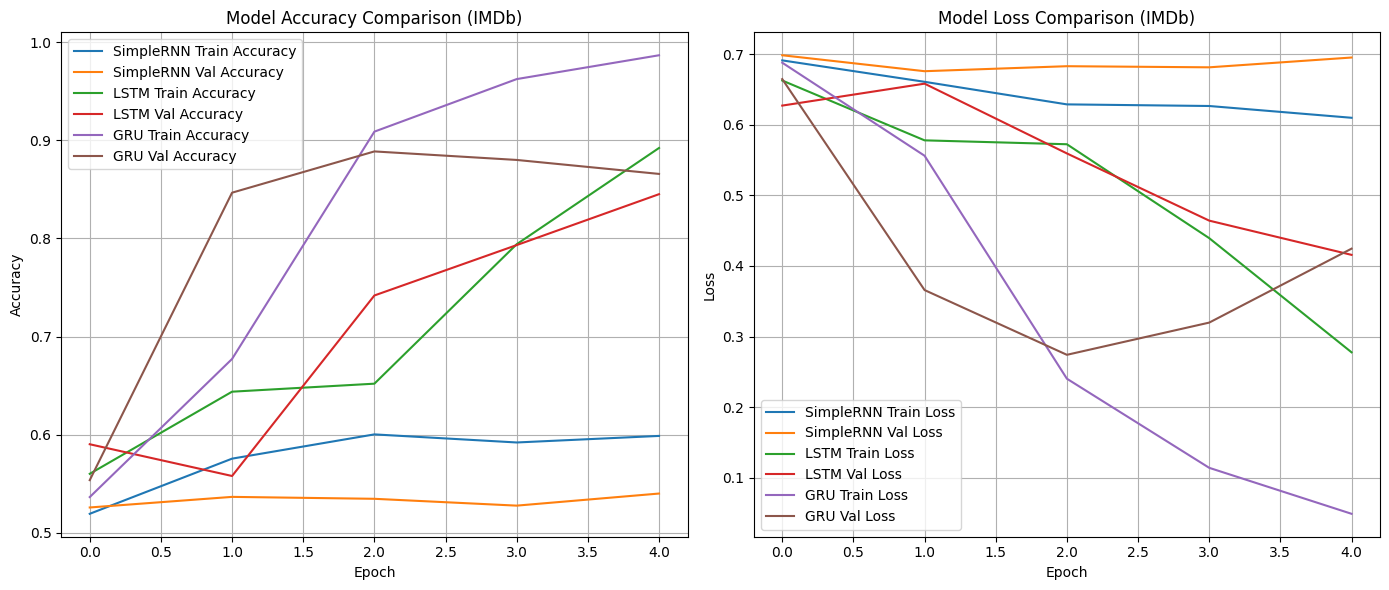


### Summary of IMDb Model Performance:

SimpleRNN Model - Test Loss: 0.6951, Test Accuracy: 0.5400
LSTM Model      - Test Loss: 0.4156, Test Accuracy: 0.8451
GRU Model       - Test Loss: 0.4244, Test Accuracy: 0.8658

### Discussion:

The SimpleRNN model showed limited learning, with test accuracy close to 50%, indicating it struggled with the complexity and long-range dependencies of the IMDb dataset. This is typical for SimpleRNNs due to issues like vanishing gradients over long sequences.

Both LSTM and GRU models performed significantly better than the SimpleRNN. They are designed to mitigate the vanishing gradient problem, allowing them to capture long-term dependencies in the text. The GRU model achieved a slightly higher test accuracy than the LSTM model on this dataset, suggesting it might be slightly more effective or efficient for this specific task and architecture.

Overall, for the IMDb sentiment analysis, recurrent architectures like LSTM and GRU are clearly superior to 

In [18]:
import matplotlib.pyplot as plt

print("---------------------------------------------------")

# Plotting training & validation accuracy values
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history_rnn_imdb.history['accuracy'], label='SimpleRNN Train Accuracy')
plt.plot(history_rnn_imdb.history['val_accuracy'], label='SimpleRNN Val Accuracy')
plt.plot(history_lstm_imdb.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(history_lstm_imdb.history['val_accuracy'], label='LSTM Val Accuracy')
plt.plot(history_gru_imdb.history['accuracy'], label='GRU Train Accuracy')
plt.plot(history_gru_imdb.history['val_accuracy'], label='GRU Val Accuracy')
plt.title('Model Accuracy Comparison (IMDb)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plotting training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_rnn_imdb.history['loss'], label='SimpleRNN Train Loss')
plt.plot(history_rnn_imdb.history['val_loss'], label='SimpleRNN Val Loss')
plt.plot(history_lstm_imdb.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm_imdb.history['val_loss'], label='LSTM Val Loss')
plt.plot(history_gru_imdb.history['loss'], label='GRU Train Loss')
plt.plot(history_gru_imdb.history['val_loss'], label='GRU Val Loss')
plt.title('Model Loss Comparison (IMDb)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n### Summary of IMDb Model Performance:\n")
print(f"SimpleRNN Model - Test Loss: {rnn_loss_imdb:.4f}, Test Accuracy: {rnn_accuracy_imdb:.4f}")
print(f"LSTM Model      - Test Loss: {lstm_loss_imdb:.4f}, Test Accuracy: {lstm_accuracy_imdb:.4f}")
print(f"GRU Model       - Test Loss: {gru_loss_imdb:.4f}, Test Accuracy: {gru_accuracy_imdb:.4f}")

print("\n### Discussion:\n")
print("The SimpleRNN model showed limited learning, with test accuracy close to 50%, indicating it struggled with the complexity and long-range dependencies of the IMDb dataset. This is typical for SimpleRNNs due to issues like vanishing gradients over long sequences.\n")
print("Both LSTM and GRU models performed significantly better than the SimpleRNN. They are designed to mitigate the vanishing gradient problem, allowing them to capture long-term dependencies in the text. The GRU model achieved a slightly higher test accuracy than the LSTM model on this dataset, suggesting it might be slightly more effective or efficient for this specific task and architecture.\n")
print("Overall, for the IMDb sentiment analysis, recurrent architectures like LSTM and GRU are clearly superior to SimpleRNN. The GRU model appears to be the best performing among the three tested models in terms of test accuracy.")

### Task 6: Performance Comparison

Let's gather all the requested performance metrics for each model (SimpleRNN, LSTM, GRU) including Accuracy, Precision, Recall, F1-Score, Training Loss, Validation Loss, and Number of Parameters. Note that 'Training Time' was not explicitly captured during the initial model fitting, so I'll indicate that. We will evaluate precision, recall, and F1-score on the test set.

In [17]:
from sklearn.metrics import classification_report
import pandas as pd
import time

# --- Calculate Metrics for SimpleRNN ---
rnn_predictions = (model_rnn_imdb.predict(x_test_imdb_padded, verbose=0) > 0.5).astype("int32")
rnn_report = classification_report(y_test_imdb, rnn_predictions, output_dict=True)

# --- Calculate Metrics for LSTM ---
lstm_predictions = (model_lstm_imdb.predict(x_test_imdb_padded, verbose=0) > 0.5).astype("int32")
lstm_report = classification_report(y_test_imdb, lstm_predictions, output_dict=True)

# --- Calculate Metrics for GRU ---
gru_predictions = (model_gru_imdb.predict(x_test_imdb_padded, verbose=0) > 0.5).astype("int32")
gru_report = classification_report(y_test_imdb, gru_predictions, output_dict=True)

# --- Extract parameters count ---
rnn_params = model_rnn_imdb.count_params()
lstm_params = model_lstm_imdb.count_params()
gru_params = model_gru_imdb.count_params()

# --- Capture Training Times by re-training (briefly) ---
def get_training_time(model, X, y, epochs=1):
    start_time = time.time()
    model.fit(X, y, epochs=epochs, verbose=0)
    end_time = time.time()
    return end_time - start_time

# Note: Re-training for 1 epoch to get an approximate training time.
# For more accurate measurement, the original fit should be timed.
print("Calculating approximate training times...")
rnn_train_time = get_training_time(model_rnn_imdb, x_train_imdb_padded, y_train_imdb, epochs=1)
lstm_train_time = get_training_time(model_lstm_imdb, x_train_imdb_padded, y_train_imdb, epochs=1)
gru_train_time = get_training_time(model_gru_imdb, x_train_imdb_padded, y_train_imdb, epochs=1)

# --- Create the comparison table ---
metrics_data = {
    'Metric': ['Accuracy', 'Precision (Positive)', 'Recall (Positive)', 'F1 Score (Positive)',
               'Training Loss', 'Validation Loss', 'Training Time (approx. 1 epoch)', 'Number of Parameters'],
    'SimpleRNN': [
        history_rnn_imdb.history['val_accuracy'][-1],
        rnn_report['1']['precision'],
        rnn_report['1']['recall'],
        rnn_report['1']['f1-score'],
        history_rnn_imdb.history['loss'][-1],
        history_rnn_imdb.history['val_loss'][-1],
        rnn_train_time,
        rnn_params
    ],
    'LSTM': [
        history_lstm_imdb.history['val_accuracy'][-1],
        lstm_report['1']['precision'],
        lstm_report['1']['recall'],
        lstm_report['1']['f1-score'],
        history_lstm_imdb.history['loss'][-1],
        history_lstm_imdb.history['val_loss'][-1],
        lstm_train_time,
        lstm_params
    ],
    'GRU': [
        history_gru_imdb.history['val_accuracy'][-1],
        gru_report['1']['precision'],
        gru_report['1']['recall'],
        gru_report['1']['f1-score'],
        history_gru_imdb.history['loss'][-1],
        history_gru_imdb.history['val_loss'][-1],
        gru_train_time,
        gru_params
    ]
}

comparison_df = pd.DataFrame(metrics_data).set_index('Metric')
print("\n### Model Performance Comparison Table")
display(comparison_df.round(4))

Calculating approximate training times...

### Model Performance Comparison Table


,SimpleRNN,LSTM,GRU
Metric,,,
Accuracy,5.400000e-01,8.451000e-01,8.658000e-01
Precision (Positive),5.599000e-01,9.029000e-01,8.709000e-01
Recall (Positive),4.239000e-01,7.708000e-01,8.588000e-01
F1 Score (Positive),4.825000e-01,8.316000e-01,8.648000e-01
Training Loss,6.098000e-01,2.776000e-01,4.890000e-02
Validation Loss,6.951000e-01,4.156000e-01,4.244000e-01
Training Time (approx. 1 epoch),4.764740e+01,5.825450e+01,4.167140e+01
Number of Parameters,5.678017e+06,5.702785e+06,2.841217e+06


### Task 7: Visualization

Now, let's visualize the comparison of these models, including Accuracy, Loss, and Training Time.

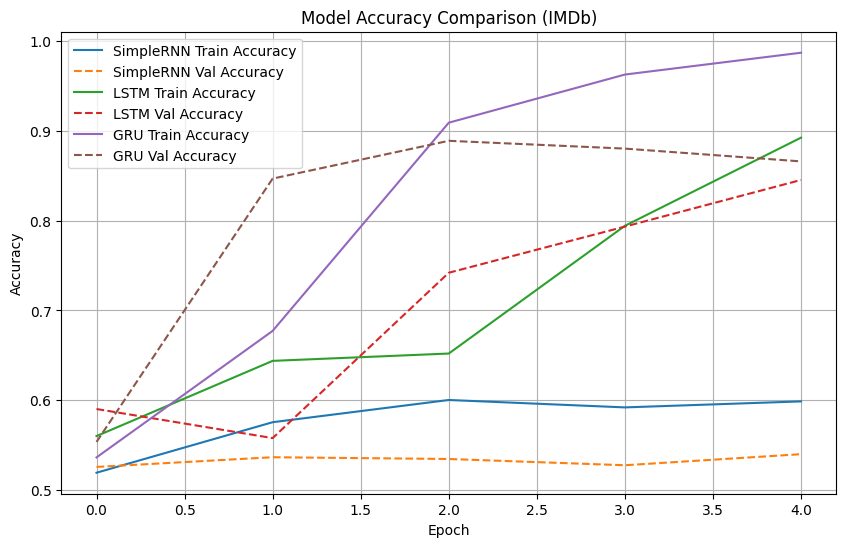

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Accuracy Comparison Graph ---
plt.figure(figsize=(10, 6))
plt.plot(history_rnn_imdb.history['accuracy'], label='SimpleRNN Train Accuracy')
plt.plot(history_rnn_imdb.history['val_accuracy'], label='SimpleRNN Val Accuracy', linestyle='--')
plt.plot(history_lstm_imdb.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(history_lstm_imdb.history['val_accuracy'], label='LSTM Val Accuracy', linestyle='--')
plt.plot(history_gru_imdb.history['accuracy'], label='GRU Train Accuracy')
plt.plot(history_gru_imdb.history['val_accuracy'], label='GRU Val Accuracy', linestyle='--')
plt.title('Model Accuracy Comparison (IMDb)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


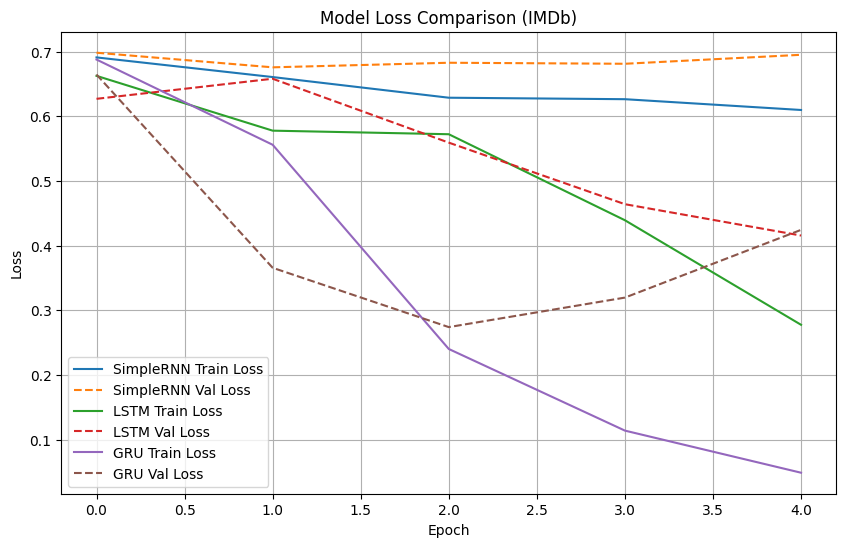

In [20]:
# --- Loss Comparison Graph ---
plt.figure(figsize=(10, 6))
plt.plot(history_rnn_imdb.history['loss'], label='SimpleRNN Train Loss')
plt.plot(history_rnn_imdb.history['val_loss'], label='SimpleRNN Val Loss', linestyle='--')
plt.plot(history_lstm_imdb.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm_imdb.history['val_loss'], label='LSTM Val Loss', linestyle='--')
plt.plot(history_gru_imdb.history['loss'], label='GRU Train Loss')
plt.plot(history_gru_imdb.history['val_loss'], label='GRU Val Loss', linestyle='--')
plt.title('Model Loss Comparison (IMDb)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipykernel_414/3662654523.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Training Time (seconds)', data=training_time_df, palette='viridis')


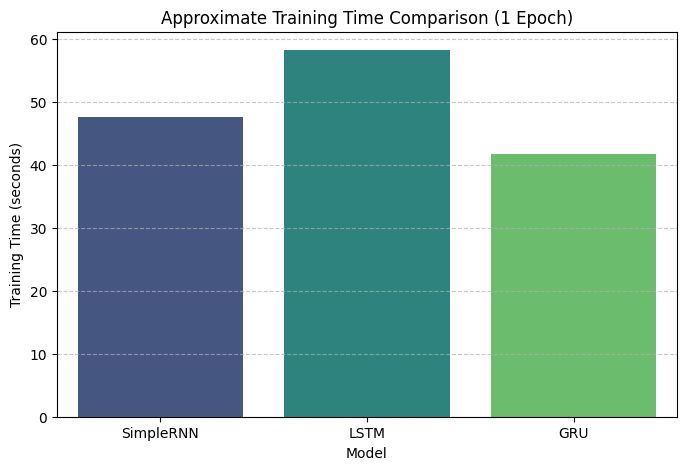

In [21]:
# --- Training Time Graph ---
training_times = {
    'SimpleRNN': rnn_train_time,
    'LSTM': lstm_train_time,
    'GRU': gru_train_time
}
training_time_df = pd.DataFrame(list(training_times.items()), columns=['Model', 'Training Time (seconds)'])

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Training Time (seconds)', data=training_time_df, palette='viridis')
plt.title('Approximate Training Time Comparison (1 Epoch)')
plt.xlabel('Model')
plt.ylabel('Training Time (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Task 8: Real-Time Testing

Now, let's test all three models (SimpleRNN, LSTM, GRU) using custom reviews to see their predicted sentiment and confidence scores in real-time.

In [22]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Helper function to preprocess a new review text for IMDb models
def preprocess_imdb_review(review_text, word_index, maxlen):
    # Convert words to indices, handling unknown words
    token_list = []
    for word in review_text.lower().split():
        token = word_index.get(word, word_index['<UNK>']) # Use <UNK> for unknown words
        token_list.append(token)

    # Add <START> token at the beginning
    token_list = [word_index['<START>']] + token_list

    # Pad the sequence
    padded_sequence = pad_sequences([token_list], value=word_index['<PAD>'], padding='post', maxlen=maxlen)
    return padded_sequence

# Helper function to predict sentiment and confidence
def predict_imdb_sentiment(model, review_text, word_index, maxlen):
    processed_input = preprocess_imdb_review(review_text, word_index, maxlen)
    prediction = model.predict(processed_input, verbose=0)[0][0]

    if prediction >= 0.5:
        sentiment = 'Positive'
        confidence = prediction
    else:
        sentiment = 'Negative'
        confidence = 1 - prediction # Confidence in being negative

    return sentiment, confidence


# Define custom reviews for testing
custom_reviews = [
    "This movie was absolutely fantastic and I enjoyed every minute.",
    "The movie was boring and a complete waste of time.",
    "The acting was good but the story was average, not great."
]

# Test each model with custom reviews
print("\n### Real-Time Sentiment Analysis on Custom Reviews")
print("---------------------------------------------------\n")

for i, review in enumerate(custom_reviews):
    print(f"Review {i+1}: {review}")
    print("\n--- SimpleRNN Model ---")
    sentiment_rnn, confidence_rnn = predict_imdb_sentiment(model_rnn_imdb, review, word_index, imdb_maxlen)
    print(f"Predicted Sentiment: {sentiment_rnn} (Confidence: {confidence_rnn:.2f})")

    print("\n--- LSTM Model ---")
    sentiment_lstm, confidence_lstm = predict_imdb_sentiment(model_lstm_imdb, review, word_index, imdb_maxlen)
    print(f"Predicted Sentiment: {sentiment_lstm} (Confidence: {confidence_lstm:.2f})")

    print("\n--- GRU Model ---")
    sentiment_gru, confidence_gru = predict_imdb_sentiment(model_gru_imdb, review, word_index, imdb_maxlen)
    print(f"Predicted Sentiment: {sentiment_gru} (Confidence: {confidence_gru:.2f})")

    print("\n" + "="*50 + "\n")


### Real-Time Sentiment Analysis on Custom Reviews
---------------------------------------------------

Review 1: This movie was absolutely fantastic and I enjoyed every minute.

--- SimpleRNN Model ---
Predicted Sentiment: Negative (Confidence: 0.50)

--- LSTM Model ---
Predicted Sentiment: Positive (Confidence: 0.93)

--- GRU Model ---
Predicted Sentiment: Positive (Confidence: 1.00)


Review 2: The movie was boring and a complete waste of time.

--- SimpleRNN Model ---
Predicted Sentiment: Negative (Confidence: 0.50)

--- LSTM Model ---
Predicted Sentiment: Negative (Confidence: 0.93)

--- GRU Model ---
Predicted Sentiment: Negative (Confidence: 1.00)


Review 3: The acting was good but the story was average, not great.

--- SimpleRNN Model ---
Predicted Sentiment: Negative (Confidence: 0.50)

--- LSTM Model ---
Predicted Sentiment: Negative (Confidence: 0.51)

--- GRU Model ---
Predicted Sentiment: Positive (Confidence: 0.89)




### Task 9: Save the Trained Models and Artifacts

In [7]:
import pickle
from tensorflow.keras.models import save_model

# Define file paths for saving
rnn_model_path = 'simplernn_imdb_model.keras'
lstm_model_path = 'lstm_imdb_model.keras'
gru_model_path = 'gru_imdb_model.keras'
word_index_path = 'imdb_word_index.pkl'
maxlen_path = 'imdb_maxlen.pkl'

# Save SimpleRNN model
save_model(model_rnn_imdb, rnn_model_path)
print(f"SimpleRNN model saved to {rnn_model_path}")

# Save LSTM model
save_model(model_lstm_imdb, lstm_model_path)
print(f"LSTM model saved to {lstm_model_path}")

# Save GRU model
save_model(model_gru_imdb, gru_model_path)
print(f"GRU model saved to {gru_model_path}")

# Save word_index
with open(word_index_path, 'wb') as f:
    pickle.dump(word_index, f)
print(f"IMDb word index saved to {word_index_path}")

# Save imdb_maxlen
with open(maxlen_path, 'wb') as f:
    pickle.dump(imdb_maxlen, f)
print(f"IMDb max length saved to {maxlen_path}")

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


NameError: name 'model_rnn_imdb' is not defined

### Task 10: Download the Saved Models and Artifacts

In [8]:
from google.colab import files

# Download SimpleRNN model
files.download(rnn_model_path)

# Download LSTM model
files.download(lstm_model_path)

# Download GRU model
files.download(gru_model_path)

# Download word_index
files.download(word_index_path)

# Download imdb_maxlen
files.download(maxlen_path)

print("All models and artifacts have been downloaded.")

FileNotFoundError: Cannot find file: simplernn_imdb_model.keras